In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import math, random

# Practical Applications and Review

1. Applications of DSP in Audio & Speech Processing
2. DSP in Image Processing & Communications
3. Overview of DSP in Embedded Systems (FPGAs, ARM)

## DSP Audio & Speech Processing

### Audio Sampling

The perception of a continuous sound, such as a note from a musical instrument, is often divided into three parts: loudness, pitch, and timbre (pronounced "timber"). **Loudness** is a measure of sound wave intensity, as previously described. **Pitch** is the frequency of the fundamental component in the sound, that is, the frequency with which the waveform repeats itself. **Timbre** is more complicated, being determined by the harmonic content of the signal. 

In spite of the very different time domain waveforms, these two signals (1kHz $\pm$ 3 kHz) sound identical. This is because hearing is based on the amplitude of the frequencies, and is **very insensitive to their phase**. The shape of the time domain waveform is only indirectly related to hearing, and usually not considered in audio systems.

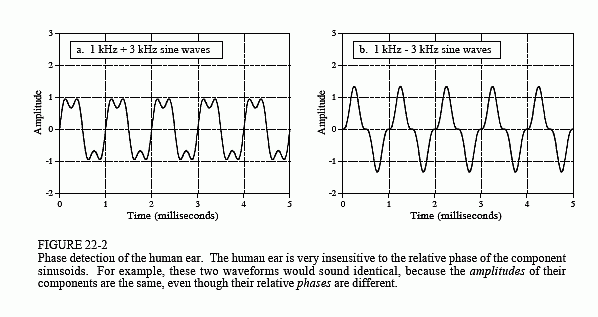

From a physics standpoint, the phase of an audio signal becomes randomized as it propagates through a complex environment. Put another way, the ear is insensitive to phase because it contains little useful information.

It is often said that timbre is determined by the shape of the waveform. This is true, but slightly misleading. The perception of timbre results from the ear detecting harmonics. While harmonic content is determined by the shape of the waveform, the insensitivity of the ear to phase makes the relationship very one-sided. That is, a particular waveform will have only one timbre, while a particular timbre has an infinite number of possible waveforms.

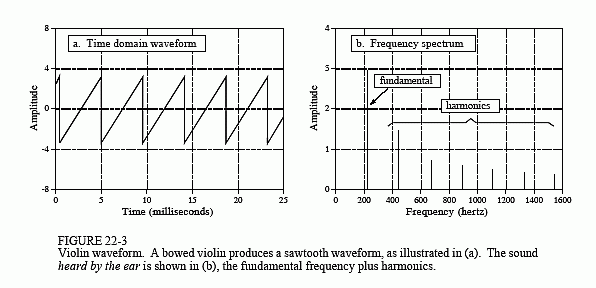

#### Sound Quality vs. Data Rate

When designing a digital audio system there are two questions that need to be asked: (1) how good does it need to sound? and (2) what data rate can be tolerated? The answer to these questions usually results in one of three categories. First, high fidelity music, where sound quality is of the greatest importance, and almost any data rate will be acceptable. Second, telephone communication, requiring natural sounding speech and a low data rate to reduce the system cost. Third, compressed speech, where reducing the data rate is very important and some unnaturalness in the sound quality can be tolerated. This includes military communication, cellular telephones, and digitally stored speech for voice mail and multimedia.

High fidelity music systems sample fast enough (44.1 kHz), and with enough precision (16 bits), that they can capture virtually all of the sounds that humans are capable of hearing. This magnificent sound quality comes at the price of a high data rate, 44.1 kHz × 16 bits = 706k bits/sec. This is pure brute force. Whereas music requires a bandwidth of 20 kHz, natural sounding speech only requires about 3.2 kHz. Even though the frequency range has been reduced to only 16% (3.2 kHz out of 20 kHz), the signal still contains 80% of the original sound information (8 out of 10 octaves). Telecommunication systems typically operate with a sampling rate of about 8 kHz, allowing natural sounding speech, but greatly reduced music quality. You are probably already familiar with this difference in sound quality: FM radio stations broadcast with a bandwidth of almost 20 kHz, while AM radio stations are limited to about 3.2 kHz. Voices sound normal on the AM stations, but the music is weak and unsatisfying.

Voice-only systems also reduce the precision from 16 bits to 12 bits per sample, with little noticeable change in the sound quality. This can be reduced to only 8 bits per sample if the quantization step size is made unequal. This is a widespread procedure called companding. An 8 kHz sampling rate, with an ADC precision of 8 bits per sample, results in a data rate of 64k bits/sec. This is the brute force data rate for natural sounding speech. Notice that speech requires less than 10% of the data rate of high fidelity music.

The data rate of 64k bits/sec represents the straightforward application of sampling and quantization theory to audio signals. Techniques for lowering the data rate further are based on compressing the data stream by removing the inherent redundancies in speech signals. One of the most efficient ways of compressing an audio signal is Linear Predictive Coding (LPC), of which there are several variations and subgroups. Depending on the speech quality required, LPC can reduce the data rate to as little as 2-6k bits/sec.

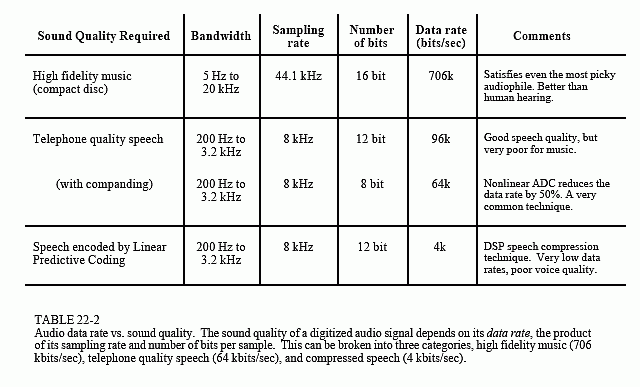

### Common Processing Tasks

### Speech Processing

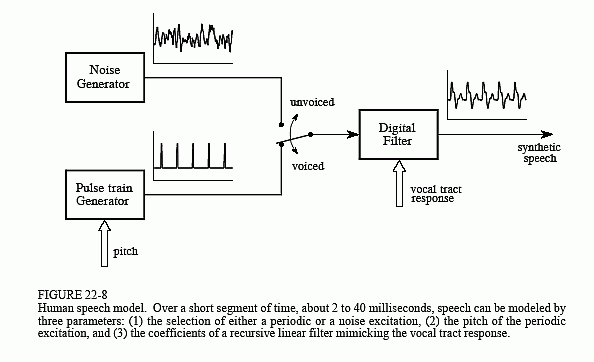

Most human speech sounds can be classified as either voiced or fricative. Voiced sounds occur when air is forced from the lungs, through the vocal cords, and out of the mouth and/or nose. The vocal cords are two thin flaps of tissue stretched across the air flow, just behind the Adam's apple. In response to varying muscle tension, the vocal cords vibrate at frequencies between 50 and 1000 Hz, resulting in periodic puffs of air being injected into the throat. Vowels are an example of voiced sounds. In Fig. 22-8, voiced sounds are represented by the pulse train generator, with the pitch (i.e., the fundamental frequency of the waveform) being an adjustable parameter.

In comparison, fricative sounds originate as random noise, not from vibration of the vocal cords. This occurs when the air flow is nearly blocked by the tongue, lips, and/or teeth, resulting in air turbulence near the constriction. Fricative sounds include: s, f, sh, z, v, and th. In the model of Fig. 22-8, fricatives are represented by a noise generator.

Both these sound sources are modified by the acoustic cavities formed from the tongue, lips, mouth, throat, and nasal passages. Since sound propagation through these structures is a linear process, it can be represented as a linear filter with an appropriately chosen impulse response. In most cases, a recursive filter is used in the model, with the recursion coefficients specifying the filter's characteristics. Because the acoustic cavities have dimensions of several centimeters, the frequency response is primarily a series of resonances in the kilohertz range. In the jargon of audio processing, these resonance peaks are called the format frequencies. By changing the relative position of the tongue and lips, the format frequencies can be changed in both frequency and amplitude.

A common way to display speech signals is the voice spectrogram, or voiceprint. The audio signal is broken into short segments, say 2 to 40 milliseconds, and the FFT used to find the frequency spectrum of each segment. These spectra are placed side-by-side, and converted into a grayscale image (low amplitude becomes light, and high amplitude becomes dark). This provides a graphical way of observing how the frequency content of speech changes with time. The segment length is chosen as a tradeoff between frequency resolution (favored by longer segments) and time resolution (favored by shorter segments).

As demonstrated by the a in rain, voiced sounds have a periodic time domain waveform, shown in (a), and a frequency spectrum that is a series of regularly spaced harmonics, shown in (b). In comparison, the s in storm, shows that fricatives have a noisy time domain signal, as in (c), and a noisy spectrum, displayed in (d). These spectra also show the shaping by the format frequencies for both sounds. Also notice that the time-frequency display of the word rain looks similar both times it is spoken.

Over a short period, say 25 milliseconds, a speech signal can be approximated by specifying three parameters: 

1. The selection of either a periodic or random noise excitation 
2. The frequency of the periodic wave (if used)
3. The coefficients of the digital filter used to mimic the vocal tract response 

Continuous speech can then be synthesized by continually updating these three parameters about 40 times a second. This approach was responsible for one the early commercial successes of DSP: the Speak & Spell, a widely marketed electronic learning aid for children. The sound quality of this type of speech synthesis is poor, sounding very mechanical and not quite human. However, it requires a very low data rate, typically only a few kbits/sec.

This is also the basis for the linear predictive coding (LPC) method of speech compression. Digitally recorded human speech is broken into short segments, and each is characterized according to the three parameters of the model. This typically requires about a dozen bytes per segment, or 2 to 6 kbytes/sec. The segment information is transmitted or stored as needed, and then reconstructed with the speech synthesizer.

Three annoyances are common in speech recognition systems: (1) The recognized speech must have distinct pauses between the words. This eliminates the need for the algorithm to deal with phrases that sound alike, but are composed of different words (i.e., spider ring and spy during). This is slow and awkward for people accustomed to speaking in an overlapping flow. (2) The vocabulary is often limited to only a few hundred words. This means that the algorithm only has to search a limited set to find the best match. As the vocabulary is made larger, the recognition time and error rate both increase. (3) The algorithm must be trained on each speaker. This requires each person using the system to speak each word to be recognized, often needing to be repeated five to ten times. This personalized database greatly increases the accuracy of the word recognition, but it is inconvenient and time consuming.

### MP3 and AAC

## DSP Image and Communications

### Image Processing

### Communications

## DSP in Embedded Systems

- Difference between general-purpose processors and DSP/embedded hardware

- Role of ARM Cortex-M and FPGAs in real-time DSP (audio, radar, telecom, etc.)

- Real-time constraints: latency, throughput, power

- Fixed-point vs floating-point computation

- Typical development workflows: C/C++, assembly, MATLAB-to-hardware pipelines (Simulink, HDL Coder)

- Example systems: hearing aids, IoT sensors, SDR (software-defined radio)

interactive(children=(IntSlider(value=8000, description='sampling_rate', max=44100, min=2000, step=1000), Outp…

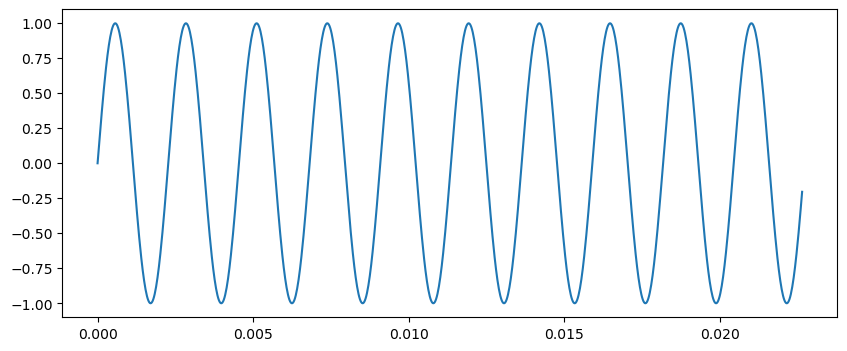

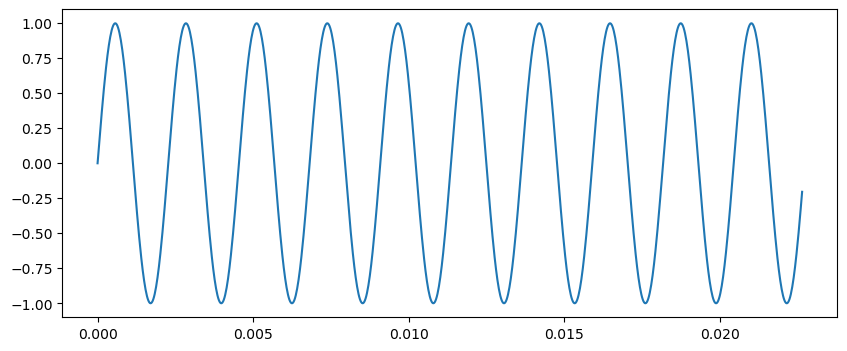

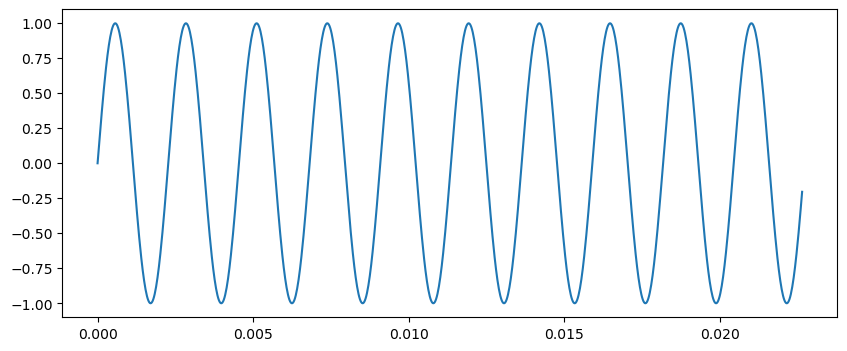

In [5]:
import sounddevice as sd
import ipywidgets as widgets

# Generate a pure tone
duration = 3.0  # seconds
freq = 440  # A4 note
sample_rate = 44100
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
signal = np.sin(2 * np.pi * freq * t)

@widgets.interact(sampling_rate=widgets.IntSlider(min=2000, max=44100, step=1000, value=8000))
def resample_and_play(sampling_rate):
    step = sample_rate // sampling_rate
    sampled_signal = signal[::step]

    # Playback: upsample to original rate so we can hear it
    playback_signal = np.repeat(sampled_signal, step)
    sd.play(playback_signal, sample_rate)

    # Plot original vs sampled
    plt.figure(figsize=(10,4))
    plt.plot(t[:1000], signal[:1000], label="Original")
    plt.plot(t[:1000:step], sampled_signal[:1000//step], 'o-', label=f"Sampled ({sampling_rate} Hz)")
    plt.legend()
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.title("Audio Sampling Demonstration")
    plt.show()


# Tasks:

1. Implement a simple noise removal filter for audio signals
2. Review and consolidate all previous concepts